<a href="https://colab.research.google.com/github/rebeca07-pedrozo/ML-/blob/main/Regresi%C3%B3n_log%C3%ADstica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carga y exploración inicial

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Cargar datos
datos = pd.read_csv('/content/aprobacion_credito_taller.csv')

# Exploración básica
print("📊 FORMA DEL DATASET:")
print(f"   Filas: {datos.shape[0]}, Columnas: {datos.shape[1]}\n")

print("📋 PRIMERAS FILAS:")
print(datos.head())

print("\n📈 DISTRIBUCIÓN DE LA TARGET:")
print(datos['aprobado'].value_counts())
print(f"\nTasa de aprobación: {datos['aprobado'].mean():.1%}")

print("\n🔍 DESCRIPCIÓN ESTADÍSTICA:")
print(datos.describe())

📊 FORMA DEL DATASET:
   Filas: 1000, Columnas: 6

📋 PRIMERAS FILAS:
   ingreso_mensual_kcop  score_buro  antiguedad_laboral_anios  \
0                8006.0         689                      15.1   
1                3164.0         458                      13.0   
2                3658.0         664                      18.6   
3                3108.0         608                       6.4   
4                2759.0         609                      22.3   

   num_creditos_activos    dti  aprobado  
0                     0  0.333         1  
1                     2  0.512         0  
2                     0  0.162         1  
3                     1  0.350         0  
4                     2  0.259         0  

📈 DISTRIBUCIÓN DE LA TARGET:
aprobado
0    726
1    274
Name: count, dtype: int64

Tasa de aprobación: 27.4%

🔍 DESCRIPCIÓN ESTADÍSTICA:
       ingreso_mensual_kcop   score_buro  antiguedad_laboral_anios  \
count           1000.000000  1000.000000                1000.00000   
mean 

# Preparación de los datos + escalamiento

In [3]:
# Separar features y target
X = datos.drop('aprobado', axis=1)
y = datos['aprobado']

# Nombres claros para referencia
nombres_features = X.columns.tolist()
print(f"✅ Features a usar: {nombres_features}\n")

# Dividir en train (70%) y test (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Escalar (IMPORTANTE para interpretabilidad de coeficientes)
escalador = StandardScaler()
X_train_scaled = escalador.fit_transform(X_train)
X_test_scaled = escalador.transform(X_test)

print(f"✅ Train size: {X_train.shape[0]}")
print(f"✅ Test size: {X_test.shape[0]}")
print(f"\n✅ Data escalada (media=0, std=1)")

✅ Features a usar: ['ingreso_mensual_kcop', 'score_buro', 'antiguedad_laboral_anios', 'num_creditos_activos', 'dti']

✅ Train size: 700
✅ Test size: 300

✅ Data escalada (media=0, std=1)


# Entrenamiento de regresión logística

In [4]:
# Entrenar modelo
modelo_logistico = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

modelo_logistico.fit(X_train_scaled, y_train)

# Predicciones en test
y_pred = modelo_logistico.predict(X_test_scaled)
y_pred_proba = modelo_logistico.predict_proba(X_test_scaled)[:, 1]

print("✅ Modelo entrenado exitosamente\n")

✅ Modelo entrenado exitosamente



#Metricas de desempeño

In [5]:
# Calcular métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)

print("=" * 50)
print("📊 MÉTRICAS EN CONJUNTO DE PRUEBA")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precisión: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"AUC-ROC:   {auc_score:.4f}")
print("=" * 50)

# Matriz de confusión
print("\n🔍 MATRIZ DE CONFUSIÓN:")
matriz_confusion = confusion_matrix(y_test, y_pred)
print(matriz_confusion)
print(f"\nVerdaderos Negativos: {matriz_confusion[0,0]}")
print(f"Falsos Positivos:     {matriz_confusion[0,1]}")
print(f"Falsos Negativos:     {matriz_confusion[1,0]}")
print(f"Verdaderos Positivos: {matriz_confusion[1,1]}")

📊 MÉTRICAS EN CONJUNTO DE PRUEBA
Accuracy:  0.8167 (81.67%)
Precisión: 0.7288 (72.88%)
Recall:    0.5244 (52.44%)
AUC-ROC:   0.8692

🔍 MATRIZ DE CONFUSIÓN:
[[202  16]
 [ 39  43]]

Verdaderos Negativos: 202
Falsos Positivos:     16
Falsos Negativos:     39
Verdaderos Positivos: 43


# Coeficientes y odds ratio

In [7]:
# Coeficientes del modelo
coeficientes = modelo_logistico.coef_[0]

# Crear tabla clara
tabla_coef = pd.DataFrame({
    'Feature': nombres_features,
    'Coeficiente': coeficientes,
    'Odds_Ratio': np.exp(coeficientes)
})

# Ordenar por valor absoluto de coeficiente
tabla_coef['Abs_Coeficiente'] = np.abs(tabla_coef['Coeficiente'])
tabla_coef = tabla_coef.sort_values('Abs_Coeficiente', ascending=False)

print("=" * 70)
print("📈 COEFICIENTES Y ODDS RATIOS")
print("=" * 70)
print(tabla_coef[['Feature', 'Coeficiente', 'Odds_Ratio']].to_string(index=False))
print("=" * 70)

# Identificar top 2 más influyentes
top_2_features = tabla_coef.head(2)['Feature'].tolist()
print(f"\n⭐ TOP 2 VARIABLES MÁS INFLUYENTES:")
for i, feature in enumerate(top_2_features, 1):
    row = tabla_coef[tabla_coef['Feature'] == feature].iloc[0]
    print(f"   {i}. {feature} (Odds Ratio: {row['Odds_Ratio']:.4f})")

📈 COEFICIENTES Y ODDS RATIOS
                 Feature  Coeficiente  Odds_Ratio
              score_buro     1.123344    3.075121
                     dti    -0.757408    0.468880
    num_creditos_activos    -0.534217    0.586128
antiguedad_laboral_anios     0.310874    1.364617
    ingreso_mensual_kcop    -0.014716    0.985392

⭐ TOP 2 VARIABLES MÁS INFLUYENTES:
   1. score_buro (Odds Ratio: 3.0751)
   2. dti (Odds Ratio: 0.4689)


#Visualización de coeficientes

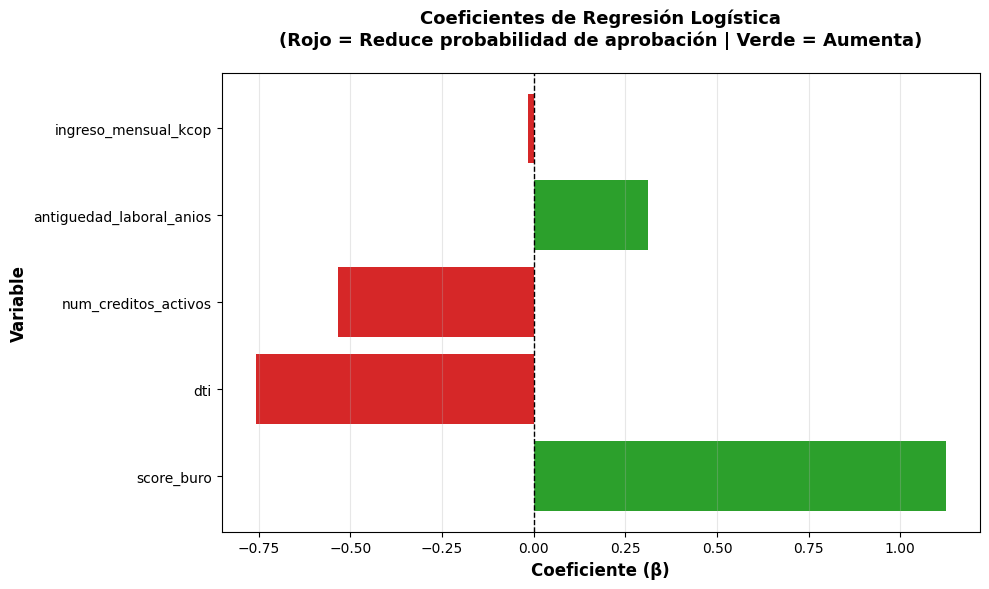

✅ Gráfico guardado: coeficientes.png


In [9]:
# Gráfico de coeficientes
plt.figure(figsize=(10, 6))
colores = ['#d62728' if x < 0 else '#2ca02c' for x in tabla_coef['Coeficiente']]
plt.barh(tabla_coef['Feature'], tabla_coef['Coeficiente'], color=colores)
plt.xlabel('Coeficiente (β)', fontsize=12, fontweight='bold')
plt.ylabel('Variable', fontsize=12, fontweight='bold')
plt.title('Coeficientes de Regresión Logística\n(Rojo = Reduce probabilidad de aprobación | Verde = Aumenta)',
          fontsize=13, fontweight='bold', pad=20)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ Gráfico guardado: coeficientes.png")

# Grafico de curva ROC

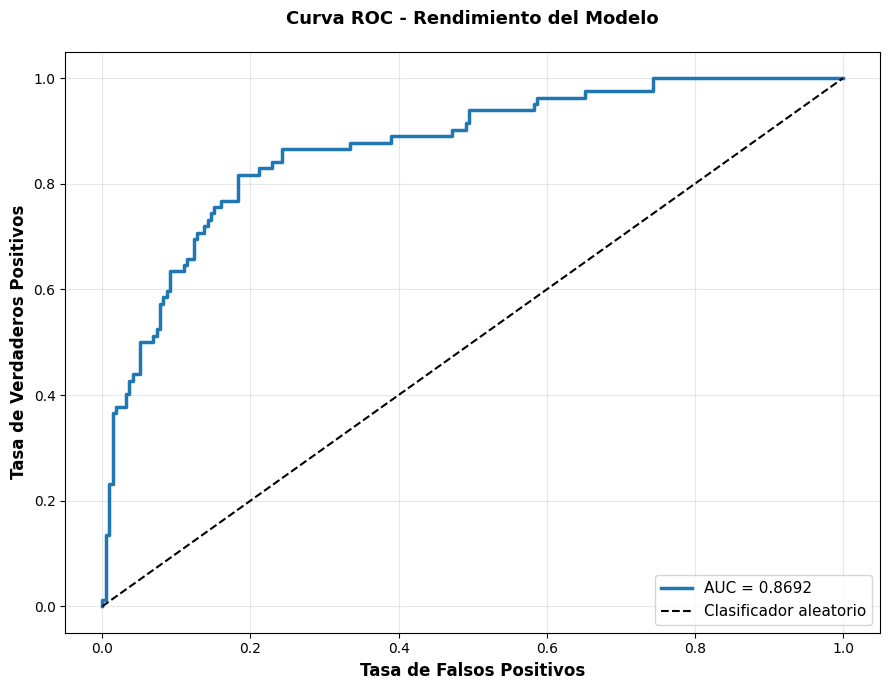

✅ Gráfico guardado: roc_curve.png


In [11]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(9, 7))
plt.plot(fpr, tpr, linewidth=2.5, label=f'AUC = {auc_score:.4f}', color='#1f77b4')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos', fontsize=12, fontweight='bold')
plt.ylabel('Tasa de Verdaderos Positivos', fontsize=12, fontweight='bold')
plt.title('Curva ROC - Rendimiento del Modelo', fontsize=13, fontweight='bold', pad=20)
plt.legend(fontsize=11, loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ Gráfico guardado: roc_curve.png")

# Matriz de confusión

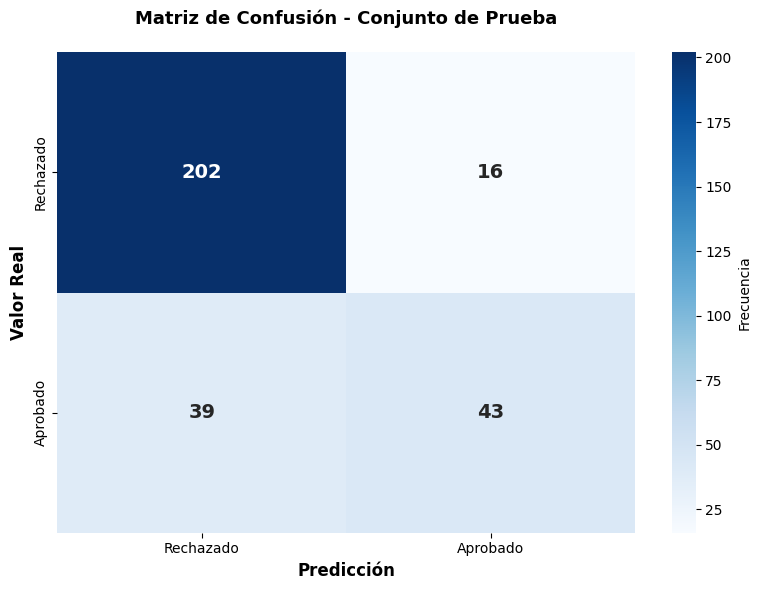

✅ Gráfico guardado: confusion_matrix.png


In [13]:
# Visualizar matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rechazado', 'Aprobado'],
            yticklabels=['Rechazado', 'Aprobado'],
            cbar_kws={'label': 'Frecuencia'},
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
plt.ylabel('Valor Real', fontsize=12, fontweight='bold')
plt.xlabel('Predicción', fontsize=12, fontweight='bold')
plt.title('Matriz de Confusión - Conjunto de Prueba', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
print("✅ Gráfico guardado: confusion_matrix.png")

# Interpretación del negocio

In [14]:
print("\n" + "=" * 80)
print("💼 INTERPRETACIÓN DE NEGOCIO - PARA ANALISTA COMERCIAL")
print("=" * 80)

# Obtener top 2 variables
feature_1 = top_2_features[0]
feature_2 = top_2_features[1]

odds_1 = tabla_coef[tabla_coef['Feature'] == feature_1]['Odds_Ratio'].values[0]
odds_2 = tabla_coef[tabla_coef['Feature'] == feature_2]['Odds_Ratio'].values[0]

coef_1 = tabla_coef[tabla_coef['Feature'] == feature_1]['Coeficiente'].values[0]
coef_2 = tabla_coef[tabla_coef['Feature'] == feature_2]['Coeficiente'].values[0]

print(f"\n🔹 VARIABLE #1: {feature_1}")
print(f"   Odds Ratio: {odds_1:.4f}")

if odds_1 > 1:
    cambio_pct = (odds_1 - 1) * 100
    print(f"   → Por cada AUMENTO DE 1 DESV. ESTÁNDAR en {feature_1}:")
    print(f"     LA PROBABILIDAD DE APROBACIÓN AUMENTA en {cambio_pct:.1f}%")
else:
    cambio_pct = (1 - odds_1) * 100
    print(f"   → Por cada AUMENTO DE 1 DESV. ESTÁNDAR en {feature_1}:")
    print(f"     LA PROBABILIDAD DE APROBACIÓN DISMINUYE en {cambio_pct:.1f}%")

print(f"\n🔹 VARIABLE #2: {feature_2}")
print(f"   Odds Ratio: {odds_2:.4f}")

if odds_2 > 1:
    cambio_pct_2 = (odds_2 - 1) * 100
    print(f"   → Por cada AUMENTO DE 1 DESV. ESTÁNDAR en {feature_2}:")
    print(f"     LA PROBABILIDAD DE APROBACIÓN AUMENTA en {cambio_pct_2:.1f}%")
else:
    cambio_pct_2 = (1 - odds_2) * 100
    print(f"   → Por cada AUMENTO DE 1 DESV. ESTÁNDAR en {feature_2}:")
    print(f"     LA PROBABILIDAD DE APROBACIÓN DISMINUYE en {cambio_pct_2:.1f}%")

print("\n" + "=" * 80)
print("📊 RESUMEN EJECUTIVO")
print("=" * 80)
print(f"• El modelo predice con ACCURACY de {accuracy*100:.1f}% en datos de prueba")
print(f"• De todos los créditos APROBADOS, captura el {recall*100:.1f}% (RECALL)")
print(f"• De las PREDICCIONES de aprobación, {precision*100:.1f}% son correctas (PRECISIÓN)")
print(f"• El AUC de {auc_score:.4f} indica un modelo {('EXCELENTE' if auc_score > 0.8 else 'BUENO' if auc_score > 0.7 else 'ACEPTABLE')}")
print("=" * 80)


💼 INTERPRETACIÓN DE NEGOCIO - PARA ANALISTA COMERCIAL

🔹 VARIABLE #1: score_buro
   Odds Ratio: 3.0751
   → Por cada AUMENTO DE 1 DESV. ESTÁNDAR en score_buro:
     LA PROBABILIDAD DE APROBACIÓN AUMENTA en 207.5%

🔹 VARIABLE #2: dti
   Odds Ratio: 0.4689
   → Por cada AUMENTO DE 1 DESV. ESTÁNDAR en dti:
     LA PROBABILIDAD DE APROBACIÓN DISMINUYE en 53.1%

📊 RESUMEN EJECUTIVO
• El modelo predice con ACCURACY de 81.7% en datos de prueba
• De todos los créditos APROBADOS, captura el 52.4% (RECALL)
• De las PREDICCIONES de aprobación, 72.9% son correctas (PRECISIÓN)
• El AUC de 0.8692 indica un modelo EXCELENTE
